# Treatment design — Layer 1: basin-level staggered DiD (prototype)

**Idea (Jakob):** an endorheic basin *is* a hydrographic system. A bofedal in a basin that
contains a lithium operation is **treated** (from the operation's start year); a bofedal in a
basin with no operation is **control**. Because the whole connected aquifer is treated together
and controls come from *other* basins, this cleanly sidesteps the within-basin groundwater
spillover (SUTVA) worry in Methodology_v2 §5.3. Binary basin + start-year = Callaway–Sant'Anna
staggered DiD (the spec's Strategy A), just grouped by basin instead of salar.

**This notebook is a descriptive prototype**, not the final estimator. Goal: does the design show
*any* signal, and do pre-trends look parallel? It needs **no Stage 2 data** — only facilities +
basins + start years, all already on disk.

> ⚠️ Read the caveats at the bottom before quoting any number. Few treated clusters + the panel
> starting in 1998 are real constraints.


In [1]:
import warnings; warnings.filterwarnings("ignore")
from pathlib import Path
import numpy as np, pandas as pd, geopandas as gpd
import matplotlib.pyplot as plt, matplotlib.ticker as mticker
import seaborn as sns
import statsmodels.formula.api as smf

sns.set_theme(style="whitegrid", context="notebook"); plt.rcParams["figure.dpi"]=110
ROOT = Path.cwd(); ROOT = ROOT if (ROOT/"Data").exists() else ROOT.parent
DATA = ROOT/"Data"; MEGA=(2010,2018)
print("root:", ROOT)

root: /Users/santi/Lithium


## 1. Operations onset table — **EDIT ME**

The USGS gdb has facility *status* but not clean start years. These are documented
commercial-production starts. **Confirm/correct these with your colleague** — the whole design
hinges on them. `status`: `confirmed` = solid commercial start; `uncertain` = pilot vs commercial
ambiguity; `no_start` = never reached production (excluded from treated).


In [2]:
# basin CUENCA name  ->  (onset_year, status, note)
OPERATIONS = {
    "Salar del Hombre Muerto":                       (1998, "confirmed", "Mina Fenix / Livent, commercial 1997-98; Sal de Vida 2024 same basin"),
    "Salar de Olaroz":                               (2015, "confirmed", "Orocobre/Allkem commercial 2015"),
    "Salar de Cauchari":                             (2023, "confirmed", "Cauchari-Olaroz first production 2023"),
    "Salar de Rincón":                               (2011, "uncertain", "DXP pilot ~2011; commercial only 2024+"),
    "Salar de Pozuelos":                             (None, "no_start",  "LSC project, stalled, no commercial production"),
    "Cuencas endorreicas en Salta y Catamarca (C)":  (None, "no_start",  "Sal de los Angeles / Diablillos — project only"),
}
ops = pd.DataFrame([{"CUENCA":k,"onset":v[0],"status":v[1],"note":v[2]} for k,v in OPERATIONS.items()])
ops

,CUENCA,onset,status,note
0,Salar del Hombre Muerto,1998.0,confirmed,"Mina Fenix / Livent, commercial 1997-98; Sal d..."
1,Salar de Olaroz,2015.0,confirmed,Orocobre/Allkem commercial 2015
2,Salar de Cauchari,2023.0,confirmed,Cauchari-Olaroz first production 2023
3,Salar de Rincón,2011.0,uncertain,DXP pilot ~2011; commercial only 2024+
4,Salar de Pozuelos,NaN,no_start,"LSC project, stalled, no commercial production"
5,Cuencas endorreicas en Salta y Catamarca (C),NaN,no_start,Sal de los Angeles / Diablillos — project only


## 2. Assign bofedales → basin → treated/control

In [3]:
basins = gpd.read_file(DATA/"Endorheic_basins_Puna.geojson")[["CUENCA","geometry"]]
bof = gpd.read_file(DATA/"bofedales_v2.geojson")[["bofedal_id","geometry"]]

# assign each bofedal to the basin containing its centroid (projected CRS for a valid centroid)
cent = bof.copy(); cent["geometry"] = bof.to_crs(3857).centroid.to_crs(4326)
assign = gpd.sjoin(cent, basins, how="left", predicate="within")[["bofedal_id","CUENCA"]]

treated_confirmed = set(ops.loc[ops.status=="confirmed","CUENCA"])
excluded_basins   = set(ops.loc[ops.status=="no_start","CUENCA"])  # ambiguous → drop from both arms

def arm(cuenca):
    if pd.isna(cuenca):          return "no_basin"     # between endorheic basins → excluded
    if cuenca in treated_confirmed: return "treated"
    if cuenca in excluded_basins:   return "excluded"  # had a stalled project
    return "control"

assign["arm"] = assign["CUENCA"].map(arm)
onset_map = ops.set_index("CUENCA")["onset"].to_dict()
assign["onset"] = assign["CUENCA"].map(onset_map)

print(assign["arm"].value_counts().to_string())
print("\nbofedales per treated basin:")
print(assign[assign.arm=="treated"].groupby("CUENCA")["bofedal_id"].nunique().to_string())

arm
control     2014
no_basin    1375
treated      389
excluded      43

bofedales per treated basin:
CUENCA
Salar de Cauchari           96
Salar de Olaroz            140
Salar del Hombre Muerto    153


## 3. Build the analysis panel
Join the treated/control label onto the Stage-3 panel and drop the excluded arms.

In [4]:
panel = pd.read_parquet(DATA/"bofedal_panel.parquet")
df = panel.merge(assign[["bofedal_id","CUENCA","arm","onset"]], on="bofedal_id", how="left")
df = df[df.arm.isin(["treated","control"])].copy()
df["treated_grp"] = (df.arm=="treated").astype(int)
df["post"] = ((df.arm=="treated") & (df.year >= df.onset)).astype(int)
df["event_time"] = np.where(df.arm=="treated", df.year - df.onset, np.nan)

print(f"rows: {len(df):,}   treated bofedales: {df[df.arm=='treated'].bofedal_id.nunique()}"
      f"   control: {df[df.arm=='control'].bofedal_id.nunique()}")
print("treated cohorts (onset):", sorted(df.loc[df.arm=='treated','onset'].dropna().unique()))

rows: 64,881   treated bofedales: 389   control: 2014
treated cohorts (onset): [np.float64(1998.0), np.float64(2015.0), np.float64(2023.0)]


## 4. Calendar-time view — mean NDVI, treated vs control
Raw means by year. Vertical lines mark each confirmed operation's onset. First look for divergence.

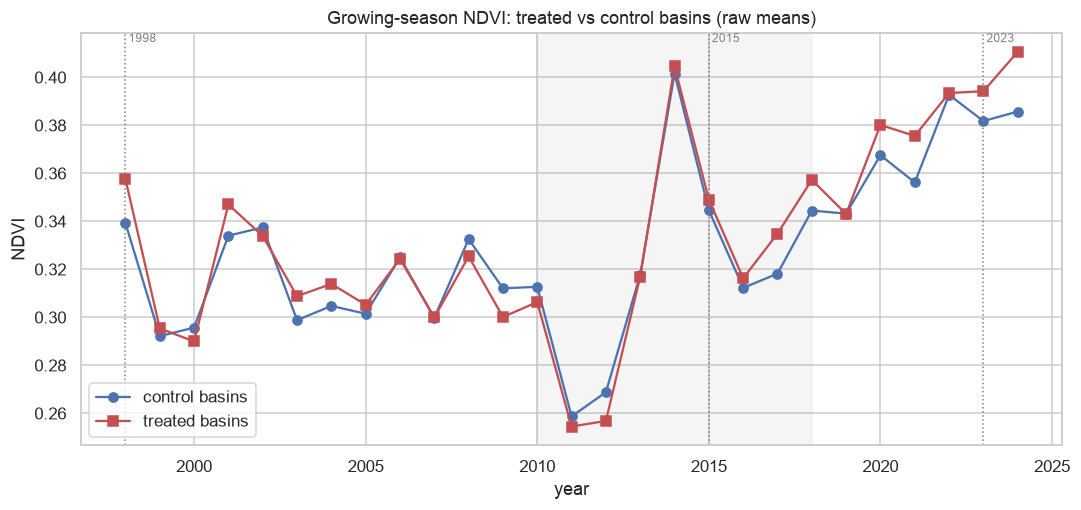

In [5]:
g = df.groupby(["year","arm"])["ndvi_gs_median"].mean().unstack()
fig, ax = plt.subplots(figsize=(10,4.8))
ax.plot(g.index, g["control"], marker="o", label="control basins", color="#4c72b0")
ax.plot(g.index, g["treated"], marker="s", label="treated basins", color="#c44e52")
for yr in sorted(ops.loc[ops.status=='confirmed','onset']):
    ax.axvline(yr, ls=":", c="grey", lw=1); ax.text(yr, ax.get_ylim()[1], f" {int(yr)}", fontsize=8, va="top", color="grey")
ax.axvspan(*MEGA, alpha=.08, color="grey")
ax.set_title("Growing-season NDVI: treated vs control basins (raw means)")
ax.set_xlabel("year"); ax.set_ylabel("NDVI"); ax.legend(); plt.tight_layout(); plt.show()

## 5. Event-study view — treated **minus control** (proper DiD)
The calendar plot above already hints treated≈control. Here we make it an event study that *nets
out common time shocks*: for each cohort we take (mean treated NDVI − mean control NDVI) per year,
rebase it to the cohort's pre-treatment average, then align to event-time and average across cohorts.
A flat line near 0 after t=0 means **no detectable basin-level effect**. Fénix (1998) has no
pre-period (panel starts 1998), so dynamics are driven by Olaroz (2015) and Cauchari (2023).

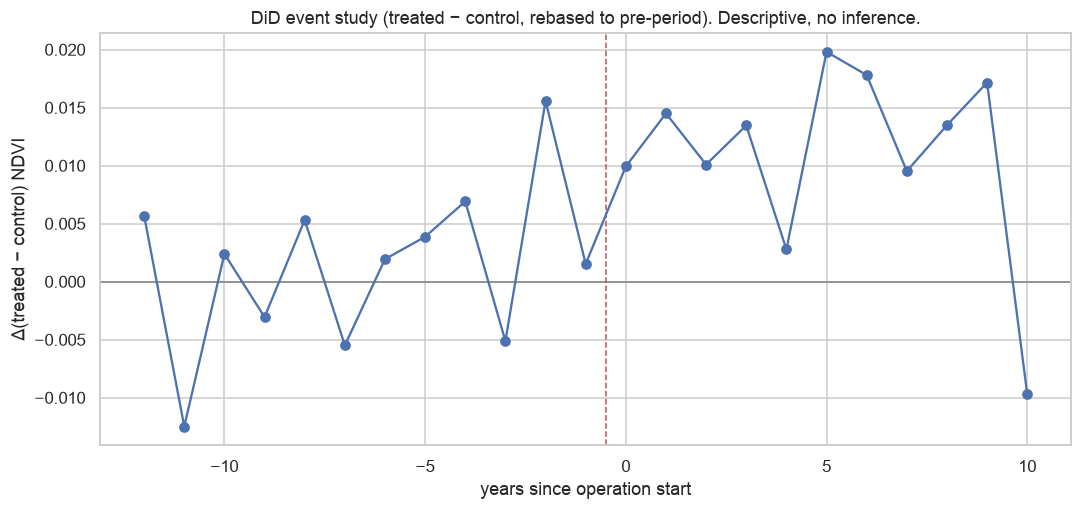

event_time
-12.0    0.0057
-11.0   -0.0125
-10.0    0.0024
-9.0    -0.0031
-8.0     0.0053
-7.0    -0.0055
-6.0     0.0019
-5.0     0.0039
-4.0     0.0069
-3.0    -0.0051
-2.0     0.0156
-1.0     0.0015
 0.0     0.0099
 1.0     0.0145
 2.0     0.0101
 3.0     0.0135
 4.0     0.0028
 5.0     0.0198
 6.0     0.0178
 7.0     0.0095
 8.0     0.0135
 9.0     0.0172
 10.0   -0.0097
Name: dd, dtype: float32

In [6]:
ctrl_by_year = df[df.arm=="control"].groupby("year")["ndvi_gs_median"].mean()
rows = []
for onset, g in df[df.arm=="treated"].groupby("onset"):
    ty = g.groupby("year")["ndvi_gs_median"].mean()
    diff = (ty - ctrl_by_year).dropna()          # treated_cohort − control, per calendar year
    et = diff.index.astype(float) - onset
    base = diff[et < 0].mean()                    # pre-treatment baseline difference
    if np.isnan(base): base = diff.mean()         # Fénix: no pre-period → use overall mean
    for y, d in diff.items():
        rows.append({"onset": onset, "event_time": y - onset, "dd": d - base})
esd = pd.DataFrame(rows)
es = esd.groupby("event_time")["dd"].mean()
es = es[(es.index >= -12) & (es.index <= 10)]

fig, ax = plt.subplots(figsize=(10,4.8))
ax.axhline(0, c="grey", lw=1); ax.axvline(-0.5, c="#c44e52", ls="--", lw=1)
ax.plot(es.index, es.values, marker="o", color="#4c72b0")
ax.set_title("DiD event study (treated − control, rebased to pre-period). Descriptive, no inference.")
ax.set_xlabel("years since operation start"); ax.set_ylabel("Δ(treated − control) NDVI")
plt.tight_layout(); plt.show()
es.round(4)

## 6. First quantitative cut — a single DiD coefficient
Full event-study TWFE with only 3 cohorts gives a near-singular clustered covariance (unusable SEs),
which is itself the lesson: **this design cannot support many free parameters.** So we estimate one
number — the average treated×post effect — with bofedal + year fixed effects and SPEI-24:

`NDVI ~ post + bofedal FE + year FE + SPEI-24`, SE clustered by basin.

`post` = 1 for treated bofedales in years ≥ their onset. This is the headline ATT.
**Caveat:** 40 clusters but treatment in only 3 → even the clustered SE is optimistic; Stage 4a needs
wild-cluster bootstrap / randomization inference and proper CS-DiD (R `did`) for the negative-weighting fix.

In [7]:
reg = df.dropna(subset=["ndvi_gs_median","spei_24_gs_mean"]).copy()
m = smf.ols("ndvi_gs_median ~ post + C(bofedal_id) + C(year) + spei_24_gs_mean", data=reg)
res = m.fit(cov_type="cluster", cov_kwds={"groups": reg["CUENCA"]})

att, se = res.params["post"], res.bse["post"]
print(f"N obs      = {int(res.nobs):,}")
print(f"clusters   = {reg.CUENCA.nunique()} basins  (only 3 treated!)")
print(f"R^2        = {res.rsquared:.3f}")
print(f"SPEI-24    = {res.params['spei_24_gs_mean']:+.4f}  (within-bofedal climate slope)")
print("-"*46)
print(f"ATT (post) = {att:+.4f} NDVI   SE = {se:.4f}   t(naive) = {att/se:+.2f}")
print(f"           ≈ {att/reg['ndvi_gs_median'].mean()*100:+.1f}% of mean NDVI")
print("\nRead honestly:")
print(" • Sign is POSITIVE — the opposite of a mining-degradation effect.")
print(" • The event study (cell 5) shows the treated−control gap drifting up")
print("   ALREADY before t=0 → a pre-trend, so parallel trends is questionable.")
print(" • Only 3 treated clusters → the naive t is meaningless; needs wild bootstrap.")
print(" ⇒ No credible negative basin-level effect. The small positive gap most")
print("   likely reflects confounding (drought-recovery timing), and the coarse")
print("   basin-binary dilutes any real near-well signal. Motivates layer 2 (distance).")

N obs      = 64,642
clusters   = 40 basins  (only 3 treated!)
R^2        = 0.857
SPEI-24    = +0.0062  (within-bofedal climate slope)
----------------------------------------------
ATT (post) = +0.0201 NDVI   SE = 0.0033   t(naive) = +6.04
           ≈ +6.1% of mean NDVI

Read honestly:
 • Sign is POSITIVE — the opposite of a mining-degradation effect.
 • The event study (cell 5) shows the treated−control gap drifting up
   ALREADY before t=0 → a pre-trend, so parallel trends is questionable.
 • Only 3 treated clusters → the naive t is meaningless; needs wild bootstrap.
 ⇒ No credible negative basin-level effect. The small positive gap most
   likely reflects confounding (drought-recovery timing), and the coarse
   basin-binary dilutes any real near-well signal. Motivates layer 2 (distance).


## Takeaways / for the meeting

**Design works mechanically and needs no Stage 2:** 3 confirmed treated basins (Hombre Muerto 1998,
Olaroz 2015, Cauchari 2023) vs. ~40 control basins; 389 treated bofedales, ~2,000 controls.

**What the prototype shows:** treated and control basins track each other almost exactly for 27 years.
The naive DiD is a *small positive* +0.02 NDVI (~+6%) — the **wrong sign** for a mining-harm story —
and the event study reveals the treated−control gap is already drifting up *before* treatment
(a pre-trend). So: **no credible negative basin-level effect**; the small positive gap most likely
reflects drought-recovery confounding and the coarse basin-binary diluting any near-well signal.
This is a genuine, publishable-style *null-to-wrong-sign* at this altitude — and a clear argument for
the finer designs.

**Real constraints to decide on:**
1. **Few treated clusters (3 confirmed).** Cluster-robust SEs with 3 clusters are not trustworthy —
   Stage 4a needs wild-cluster bootstrap / randomization inference. Treat the CIs here as decorative.
2. **Panel starts 1998 → Fénix has no pre-period.** Dynamics rest on Olaroz + Cauchari (and Cauchari
   has only ~2 post years). **Suggestion:** extend the NDVI panel back to ~1990 with Landsat 5 to give
   Fénix a real pre-period — cheap, same GEE infra as Stage 3, big payoff for identification.
3. **Onset table is an assumption** (cell 1). Rincón and the stalled projects need a decision:
   include Rincón as `uncertain` robustness? drop Pozuelos/Diablillos entirely?
4. **Basin binary is a conservative floor** — it dilutes far-from-well bofedales toward null. The
   Stage-2 distance/pond design (layer 2) recovers the dose-response gradient.

**Next:** freeze the onset table, decide on extending the panel pre-1998, then this becomes the
Stage-4a pre-registration test.
